<a href="https://colab.research.google.com/github/safaldev12/DOCUMENT/blob/main/deep_learning_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell1 - Install and Import Libraries

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.preprocessing import image as keras_image

# VGG-19
from tensorflow.keras.applications.vgg19 import (
    VGG19,
    preprocess_input as vgg19_preprocess,
    decode_predictions as vgg19_decode
)

# ResNet-152
from tensorflow.keras.applications.resnet import (
    ResNet152,
    preprocess_input as resnet_preprocess,
    decode_predictions as resnet_decode
)

print(f"TensorFlow version: {tf.__version__}")
print(" All imports successful!")

TensorFlow version: 2.19.0
✅ All imports successful!


Cell 2 _ Uploading 10 test images

In [2]:
from google.colab import files

print(" Please upload your 10 test images (jpg/jpeg/png)...")
uploaded = files.upload()   # A file picker dialog will appear

IMAGE_DIR = "/content/test_images/"
os.makedirs(IMAGE_DIR, exist_ok=True)

# Move uploaded files into the folder
for filename in uploaded.keys():
    dest = os.path.join(IMAGE_DIR, filename)
    with open(dest, 'wb') as f:
        f.write(uploaded[filename])
    print(f"  Saved: {dest}")

print("\n Upload complete!")

 Please upload your 10 test images (jpg/jpeg/png)...


Saving rose.jpeg to rose.jpeg
Saving koala.jpg to koala.jpg
Saving hydrant.jpg to hydrant.jpg
Saving headphone.jpg to headphone.jpg
Saving cafe.jpg to cafe.jpg
Saving Carrot.jpg to Carrot.jpg
Saving Car.jpg to Car.jpg
Saving Bucket.jpg to Bucket.jpg
Saving Bicycles.jpg to Bicycles.jpg
Saving Aeroplane.jpg to Aeroplane.jpg
  Saved: /content/test_images/rose.jpeg
  Saved: /content/test_images/koala.jpg
  Saved: /content/test_images/hydrant.jpg
  Saved: /content/test_images/headphone.jpg
  Saved: /content/test_images/cafe.jpg
  Saved: /content/test_images/Carrot.jpg
  Saved: /content/test_images/Car.jpg
  Saved: /content/test_images/Bucket.jpg
  Saved: /content/test_images/Bicycles.jpg
  Saved: /content/test_images/Aeroplane.jpg

 Upload complete!


In [3]:
IMAGE_DIR = "/content/test_images/"   # change if you used Drive

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])[:10]

print(f"Found {len(image_files)} images:")
for i, f in enumerate(image_files, 1):
    print(f"  {i:2d}. {f}")

assert len(image_files) >= 10, "  Need at least 10 images!"

Found 10 images:
   1. Aeroplane.jpg
   2. Bicycles.jpg
   3. Bucket.jpg
   4. Car.jpg
   5. Carrot.jpg
   6. cafe.jpg
   7. headphone.jpg
   8. hydrant.jpg
   9. koala.jpg
  10. rose.jpeg


#Part1_ VGG-19

In [4]:
print("Loading VGG-19 with ImageNet weights...")
vgg19_model = VGG19(weights='imagenet', include_top=True, input_shape=(224, 224, 3))

print("\n" + "="*60)
print("  VGG-19 MODEL SUMMARY")
print("="*60)
vgg19_model.summary()

total_params = vgg19_model.count_params()
print(f"\n Total Parameters : {total_params:,}")
print(f" Trainable Params : {sum([np.prod(w.shape) for w in vgg19_model.trainable_weights]):,}")

Loading VGG-19 with ImageNet weights...
574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step

  VGG-19 MODEL SUMMARY


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)


📊 Total Parameters : 143,667,240
📊 Trainable Params : 143,667,240


In [5]:
def predict_image(model, img_path, preprocess_fn, decode_fn, target_size=(224, 224)):
    """Load an image, preprocess it, run prediction, return top-3 labels."""
    img = keras_image.load_img(img_path, target_size=target_size)
    x   = keras_image.img_to_array(img)
    x   = np.expand_dims(x, axis=0)
    x   = preprocess_fn(x)
    preds   = model.predict(x, verbose=0)
    decoded = decode_fn(preds, top=3)[0]
    return decoded   # list of (id, label, probability)

print(" Helper function ready!")

 Helper function ready!


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


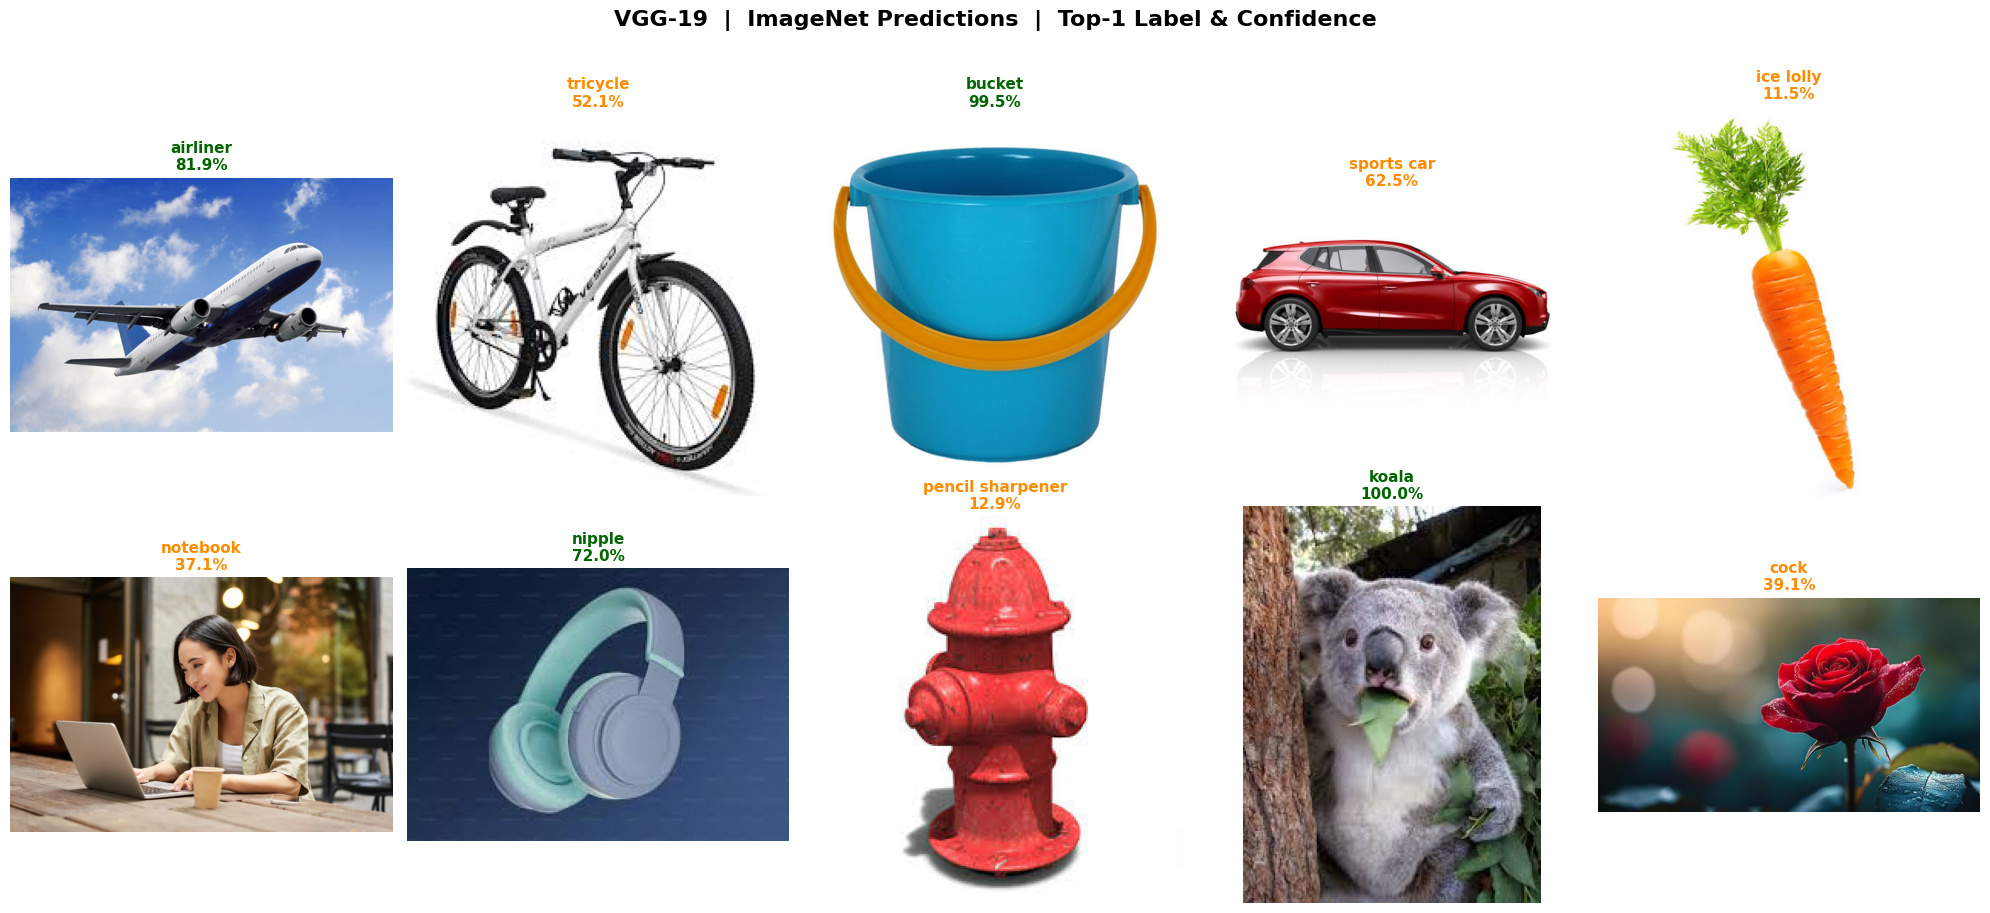


 VGG-19 predictions complete! Saved to /content/vgg19_predictions.png


In [6]:
vgg19_results = []   # store for comparison later

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle("VGG-19  |  ImageNet Predictions  |  Top-1 Label & Confidence",
             fontsize=16, fontweight='bold', y=1.01)

for idx, img_file in enumerate(image_files):
    img_path = os.path.join(IMAGE_DIR, img_file)
    preds = predict_image(vgg19_model, img_path, vgg19_preprocess, vgg19_decode)
    vgg19_results.append((img_file, preds))

    top_label = preds[0][1].replace('_', ' ')
    top_conf  = preds[0][2] * 100

    ax = axes[idx // 5][idx % 5]
    display_img = keras_image.load_img(img_path)
    ax.imshow(display_img)
    ax.set_title(
        f"{top_label}\n{top_conf:.1f}%",
        fontsize=11, fontweight='bold',
        color='darkgreen' if top_conf >= 70 else 'darkorange'
    )
    ax.axis('off')

    # small caption with top-3
    caption = "\n".join([f"{p[1].replace('_',' ')} ({p[2]*100:.1f}%)" for p in preds])
    ax.set_xlabel(caption, fontsize=7, ha='center')

plt.tight_layout()
plt.savefig("/content/vgg19_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n VGG-19 predictions complete! Saved to /content/vgg19_predictions.png")

#Part2 _ResNet-152

In [7]:
import gc
tf.keras.backend.clear_session()
gc.collect()
print(" Memory cleared — ready to load ResNet-152")

 Memory cleared — ready to load ResNet-152


In [8]:
print("Loading ResNet-152 with ImageNet weights...")
resnet152_model = ResNet152(weights='imagenet', include_top=True, input_shape=(224, 224, 3))

print("\n" + "="*60)
print("  ResNet-152 MODEL SUMMARY")
print("="*60)
resnet152_model.summary()

total_params = resnet152_model.count_params()
print(f"\n Total Parameters : {total_params:,}")
print(f" Trainable Params : {sum([np.prod(w.shape) for w in resnet152_model.trainable_weights]):,}")

Loading ResNet-152 with ImageNet weights...
242900224/242900224 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

  ResNet-152 MODEL SUMMARY


Model: "resnet152"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 60,419,944 (230.48 MB)

 Trainable params: 60,268,520 (229.91 MB)

 Non-trainable params: 151,424 (591.50 KB)


📊 Total Parameters : 60,419,944
📊 Trainable Params : 60,268,520


In [10]:
try:
    _ = vgg19_results
    print(" vgg19_results still in memory — no action needed")
except NameError:
    print("⚠️  vgg19_results lost after memory clear — re-running VGG-19 predictions...")
    vgg19_temp = VGG19(weights='imagenet')
    vgg19_results = []
    for img_file in image_files:
        img_path = os.path.join(IMAGE_DIR, img_file)
        preds = predict_image(vgg19_temp, img_path, vgg19_preprocess, vgg19_decode)
        vgg19_results.append((img_file, preds))
    del vgg19_temp
    print(" VGG-19 results restored")

 vgg19_results still in memory — no action needed


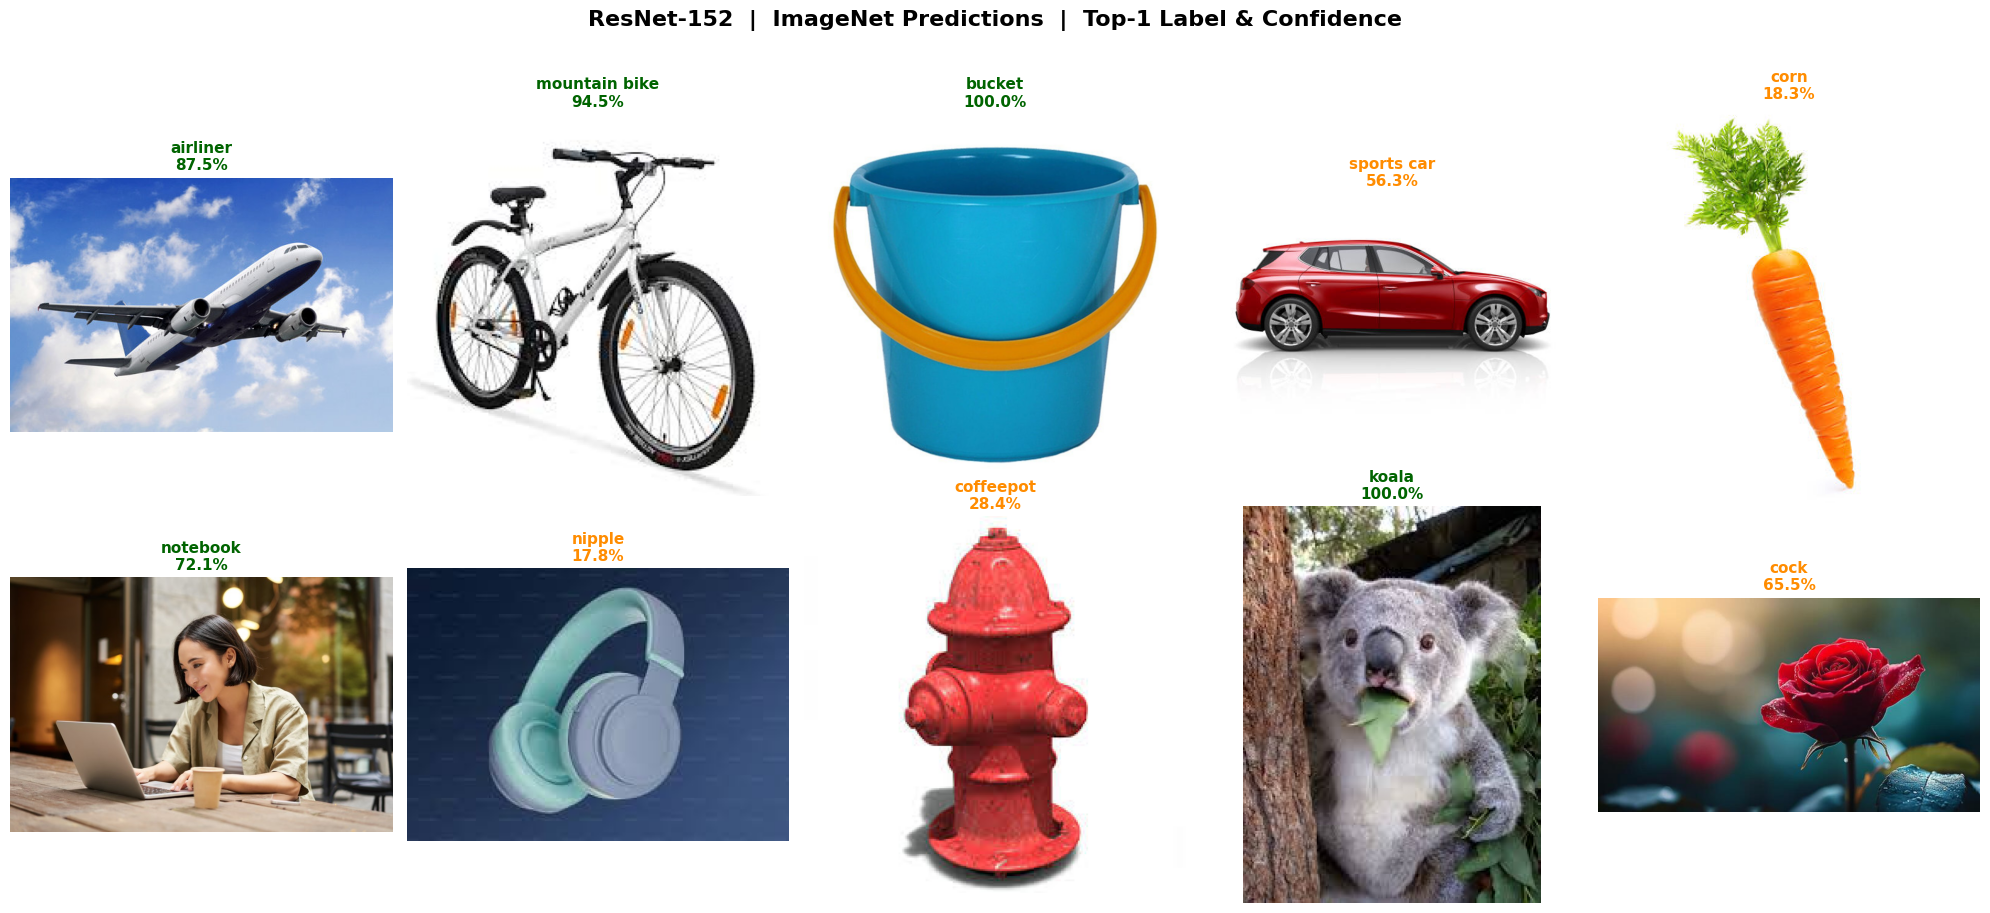


✅ ResNet-152 predictions complete! Saved to /content/resnet152_predictions.png


In [11]:
resnet_results = []

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle("ResNet-152  |  ImageNet Predictions  |  Top-1 Label & Confidence",
             fontsize=16, fontweight='bold', y=1.01)

for idx, img_file in enumerate(image_files):
    img_path = os.path.join(IMAGE_DIR, img_file)
    preds = predict_image(resnet152_model, img_path, resnet_preprocess, resnet_decode)
    resnet_results.append((img_file, preds))

    top_label = preds[0][1].replace('_', ' ')
    top_conf  = preds[0][2] * 100

    ax = axes[idx // 5][idx % 5]
    display_img = keras_image.load_img(img_path)
    ax.imshow(display_img)
    ax.set_title(
        f"{top_label}\n{top_conf:.1f}%",
        fontsize=11, fontweight='bold',
        color='darkgreen' if top_conf >= 70 else 'darkorange'
    )
    ax.axis('off')

    caption = "\n".join([f"{p[1].replace('_',' ')} ({p[2]*100:.1f}%)" for p in preds])
    ax.set_xlabel(caption, fontsize=7, ha='center')

plt.tight_layout()
plt.savefig("/content/resnet152_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ ResNet-152 predictions complete! Saved to /content/resnet152_predictions.png")

In [12]:
print("\n" + "="*90)
print(f"{'Image':<22} | {'VGG-19 Prediction':<28} | {'Conf':>6} | {'ResNet-152 Prediction':<28} | {'Conf':>6}")
print("="*90)

for (img_file, vgg_preds), (_, res_preds) in zip(vgg19_results, resnet_results):
    name     = img_file[:20]
    vgg_lbl  = vgg_preds[0][1].replace('_', ' ')[:26]
    vgg_conf = vgg_preds[0][2] * 100
    res_lbl  = res_preds[0][1].replace('_', ' ')[:26]
    res_conf = res_preds[0][2] * 100
    match    = "" if vgg_lbl.split()[0].lower() == res_lbl.split()[0].lower() else "❌"
    print(f"{name:<22} | {vgg_lbl:<28} | {vgg_conf:5.1f}% | {res_lbl:<28} | {res_conf:5.1f}%  {match}")

print("="*90)

# Agreement rate
agree = sum(
    1 for (_, v), (_, r) in zip(vgg19_results, resnet_results)
    if v[0][1].split('_')[0].lower() == r[0][1].split('_')[0].lower()
)
print(f"\n Models agreed on {agree}/10 images ({agree*10}%)")


Image                  | VGG-19 Prediction            |   Conf | ResNet-152 Prediction        |   Conf
Aeroplane.jpg          | airliner                     |  81.9% | airliner                     |  87.5%  
Bicycles.jpg           | tricycle                     |  52.1% | mountain bike                |  94.5%  ❌
Bucket.jpg             | bucket                       |  99.5% | bucket                       | 100.0%  
Car.jpg                | sports car                   |  62.5% | sports car                   |  56.3%  
Carrot.jpg             | ice lolly                    |  11.5% | corn                         |  18.3%  ❌
cafe.jpg               | notebook                     |  37.1% | notebook                     |  72.1%  
headphone.jpg          | nipple                       |  72.0% | nipple                       |  17.8%  
hydrant.jpg            | pencil sharpener             |  12.9% | coffeepot                    |  28.4%  ❌
koala.jpg              | koala                       